# Phase 3 — Modélisation : Benchmark de classification

**Objectif :** Entraîner et comparer tous les modèles sur la tâche de prédiction de direction J+1.

**Input :** `data/X_train.pkl`, `data/X_val.pkl`, `data/X_test.pkl`, `data/y_*.pkl` (générés par `02_preprocessing.py`)

**Métrique principale :** F1-score (classe 1 = hausse)

In [18]:
# Rechargement automatique des modules locaux à chaque modification
%load_ext autoreload
%autoreload 2

import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, "modèle llm")

DATA_DIR   = Path("data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Chargement des splits pré-calculés par la Phase 2 (preprocessing)
def load_pkl(name):
    with open(DATA_DIR / f"{name}.pkl", "rb") as f:
        return pickle.load(f)

X_train = load_pkl("X_train")
X_val   = load_pkl("X_val")
X_test  = load_pkl("X_test")
y_train = load_pkl("y_train")
y_val   = load_pkl("y_val")
y_test  = load_pkl("y_test")

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}  |  hausse : {y_train.mean():.2%}")
print(f"X_val   : {X_val.shape}  |  y_val   : {y_val.shape}  |  hausse : {y_val.mean():.2%}")
print(f"X_test  : {X_test.shape}  |  y_test  : {y_test.shape}  |  hausse : {y_test.mean():.2%}")
print(f"\nFeatures ({X_train.shape[1]}) :")
print(list(X_train.columns))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
X_train : (1177, 74)  |  y_train : (1177,)  |  hausse : 50.64%
X_val   : (365, 74)  |  y_val   : (365,)  |  hausse : 53.97%
X_test  : (821, 74)  |  y_test  : (821,)  |  hausse : 50.43%

Features (74) :
['ret_1d_btc', 'ret_3d_btc', 'ret_7d_btc', 'ret_14d_btc', 'ret_30d_btc', 'vol_7d_btc', 'vol_30d_btc', 'ret_1d_gold', 'ret_3d_gold', 'ret_7d_gold', 'ret_14d_gold', 'ret_30d_gold', 'vol_7d_gold', 'vol_30d_gold', 'ret_1d_eth', 'ret_3d_eth', 'ret_7d_eth', 'ret_14d_eth', 'ret_30d_eth', 'vol_7d_eth', 'vol_30d_eth', 'ret_1d_sp500', 'ret_3d_sp500', 'ret_7d_sp500', 'ret_14d_sp500', 'ret_30d_sp500', 'vol_7d_sp500', 'vol_30d_sp500', 'ret_1d_dxy', 'ret_3d_dxy', 'ret_7d_dxy', 'ret_14d_dxy', 'ret_30d_dxy', 'vol_7d_dxy', 'vol_30d_dxy', 'ret_1d_vix', 'ret_3d_vix', 'ret_7d_vix', 'ret_14d_vix', 'ret_30d_vix', 'vol_7d_vix', 'vol_30d_vix', 'ret_1d_us10y', 'ret_3d_us10y', 'ret_7d_us10y', 'ret_14d_us10y', 'ret_30d_us10y', 

## Groupe 1 — Baselines sklearn

Les modèles sklearn n'utilisent pas de séquences temporelles : ils voient chaque jour comme un vecteur de features indépendant. Validation par `TimeSeriesSplit` pour respecter la chronologie.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Concaténation train+val pour la cross-validation temporelle
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# TimeSeriesSplit respecte l'ordre chronologique (pas de shuffle)
tscv = TimeSeriesSplit(n_splits=5)

sklearn_models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":   LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":         RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=300, random_state=42),
}

# Évaluation croisée temporelle — le F1 Dummy sert de baseline à battre
sklearn_results = {}
print(f"{'Modèle':<25} {'CV F1 (mean)':>12} {'CV F1 (std)':>11}")
print("-" * 50)
for name, clf in sklearn_models.items():
    cv_f1 = cross_val_score(clf, X_trainval, y_trainval,
                            cv=tscv, scoring="f1", n_jobs=-1)
    sklearn_results[name] = {"cv_f1_mean": cv_f1.mean(), "cv_f1_std": cv_f1.std()}
    print(f"{name:<25} {cv_f1.mean():>12.4f} ± {cv_f1.std():.4f}")


Modèle                    CV F1 (mean) CV F1 (std)
--------------------------------------------------
Dummy (most_frequent)           0.5372 ± 0.2692
Logistic Regression             0.4555 ± 0.1791
Random Forest                   0.4682 ± 0.1339
Gradient Boosting               0.4873 ± 0.0522


In [20]:
# Entraînement final sur train uniquement, évaluation sur val pour la sélection de modèle
sklearn_val_results = {}
for name, clf in sklearn_models.items():
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_val)[:, 1] if hasattr(clf, "predict_proba") else clf.predict(X_val)
    y_pred = (y_prob >= 0.5).astype(int)
    sklearn_val_results[name] = {
        "F1":       f1_score(y_val, y_pred, zero_division=0),
        "AUC-ROC":  roc_auc_score(y_val, y_prob),
        "Accuracy": accuracy_score(y_val, y_pred),
    }

pd.DataFrame(sklearn_val_results).T.sort_values("F1", ascending=False)


,F1,AUC-ROC,Accuracy
Dummy (most_frequent),0.701068,0.500000,0.539726
Random Forest,0.497110,0.535609,0.523288
Gradient Boosting,0.467692,0.555958,0.526027
Logistic Regression,0.000000,0.502478,0.460274


## Importance des features (Random Forest)

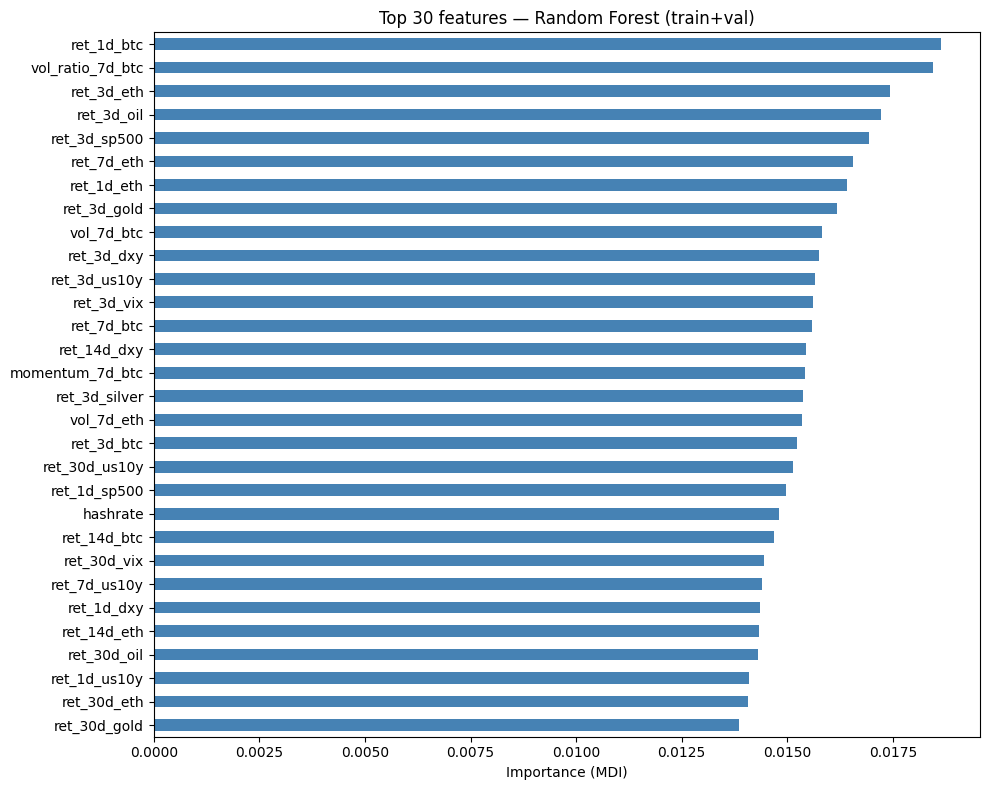


Top 10 features :
  ret_1d_btc                     0.0186
  vol_ratio_7d_btc               0.0184
  ret_3d_eth                     0.0174
  ret_3d_oil                     0.0172
  ret_3d_sp500                   0.0169
  ret_7d_eth                     0.0166
  ret_1d_eth                     0.0164
  ret_3d_gold                    0.0162
  vol_7d_btc                     0.0158
  ret_3d_dxy                     0.0158


In [21]:
# Entraînement d'une RF dédiée sur train+val pour l'importance des features
rf_importance = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_importance.fit(X_trainval, y_trainval)

# Importance MDI (Mean Decrease Impurity) triée par ordre décroissant
importances = pd.Series(rf_importance.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Affichage — top 30
top_n = 30
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(top_n).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Importance (MDI)")
ax.set_title(f"Top {top_n} features — Random Forest (train+val)")
plt.tight_layout()
plt.show()

print(f"\nTop 10 features :")
for feat, imp in importances.head(10).items():
    print(f"  {feat:<30} {imp:.4f}")


## Groupe 2 — Deep Learning PyTorch (séquences temporelles)

Les modèles DL utilisent des séquences de 60 jours. Input shape : `(n_samples, 60, n_features)`.

In [22]:
from sklearn.preprocessing import StandardScaler
from scripts_models.config import SEQUENCE_LENGTH, EPOCHS, LEARNING_RATE, BATCH_SIZE, EARLY_STOPPING_PATIENCE
from scripts_models.config import LSTM_CONFIG, GRU_CONFIG, CNN_LSTM_CONFIG, TRANSFORMER_CONFIG, TFT_CONFIG
from scripts_models.trainer import Trainer
from scripts_models.metrics import evaluate_model, print_evaluation

SEQ_LEN = SEQUENCE_LENGTH  # 60 jours

# Normalisation StandardScaler (fit sur train uniquement pour éviter le data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Transformation en séquences glissantes de longueur SEQ_LEN pour les modèles récurrents
def make_sequences(X: pd.DataFrame, y: pd.Series, seq_len: int):
    X_arr = X.values
    y_arr = y.values
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_train, SEQ_LEN)
X_vl_seq, y_vl_seq = make_sequences(X_val_scaled,   y_val,   SEQ_LEN)
X_te_seq, y_te_seq = make_sequences(X_test_scaled,  y_test,  SEQ_LEN)

n_features = X_tr_seq.shape[2]
print(f"Séquences — Train: {X_tr_seq.shape} | Val: {X_vl_seq.shape} | Test: {X_te_seq.shape}")
print(f"n_features = {n_features}")


Séquences — Train: (1117, 60, 74) | Val: (305, 60, 74) | Test: (761, 60, 74)
n_features = 74


In [23]:
from scripts_models.lstm_model import LSTMModel
from scripts_models.gru_model import GRUModel
from scripts_models.cnn_lstm_model import CNNLSTMModel
from scripts_models.transformer_model import TransformerModel
from scripts_models.tft_model import SimplifiedTFT
import time
import torch

dl_results = {}
MODELS_DIR.mkdir(exist_ok=True)

# Sauvegarde/chargement des poids pour éviter de ré-entraîner à chaque exécution
def save_trainer(trainer, name):
    path = MODELS_DIR / f'{name}.pt'
    torch.save({
        'model_state': trainer.model.state_dict(),
        'metrics_val': None,
    }, path)

def load_trainer(trainer, name):
    path = MODELS_DIR / f'{name}.pt'
    checkpoint = torch.load(path, map_location=trainer.device)
    trainer.model.load_state_dict(checkpoint['model_state'])
    return trainer

def run_dl_model(model, name):
    """Entraîne (ou charge) un modèle DL, l'évalue sur val et stocke les résultats."""
    path = MODELS_DIR / f'{name}.pt'
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parametres : {n_params:,}')

    trainer = Trainer(model=model, learning_rate=LEARNING_RATE,
                      batch_size=BATCH_SIZE, epochs=EPOCHS,
                      patience=EARLY_STOPPING_PATIENCE)

    # Chargement depuis le disque si déjà entraîné, sinon entraînement complet
    if path.exists():
        print(f'  -> Chargement depuis {path}')
        load_trainer(trainer, name)
    else:
        t0 = time.time()
        trainer.train(X_tr_seq, y_tr_seq, X_vl_seq, y_vl_seq, verbose=True)
        elapsed = time.time() - t0
        save_trainer(trainer, name)
        print(f'  -> Modele sauvegarde -> {path}')

    y_prob_val  = trainer.predict(X_vl_seq)
    results_val = evaluate_model(y_vl_seq, y_prob_val, name)
    results_val['n_params'] = n_params
    print_evaluation(results_val)
    dl_results[name] = {'trainer': trainer, 'metrics_val': results_val}
    return trainer

# Lancement de tous les modèles deep learning
# --- LSTM ---
run_dl_model(LSTMModel(n_features, LSTM_CONFIG['hidden_size'],
                        LSTM_CONFIG['num_layers'], LSTM_CONFIG['dropout']), 'LSTM')

# --- BiLSTM (lecture bidirectionnelle de la séquence) ---
run_dl_model(LSTMModel(n_features, LSTM_CONFIG['hidden_size'],
                        LSTM_CONFIG['num_layers'], LSTM_CONFIG['dropout'],
                        bidirectional=True), 'BiLSTM')

# --- GRU ---
run_dl_model(GRUModel(n_features, GRU_CONFIG['hidden_size'],
                       GRU_CONFIG['num_layers'], GRU_CONFIG['dropout']), 'GRU')

# --- CNN-LSTM (extraction locale puis mémoire temporelle) ---
run_dl_model(CNNLSTMModel(n_features, CNN_LSTM_CONFIG['cnn_filters'],
                           CNN_LSTM_CONFIG['cnn_kernel_size'],
                           CNN_LSTM_CONFIG['lstm_hidden_size'],
                           CNN_LSTM_CONFIG['lstm_num_layers'],
                           CNN_LSTM_CONFIG['dropout']), 'CNN-LSTM')

# --- Transformer (attention multi-têtes sur la séquence) ---
run_dl_model(TransformerModel(n_features, TRANSFORMER_CONFIG['d_model'],
                               TRANSFORMER_CONFIG['nhead'],
                               TRANSFORMER_CONFIG['num_encoder_layers'],
                               TRANSFORMER_CONFIG['dim_feedforward'],
                               TRANSFORMER_CONFIG['dropout']), 'Transformer')

# --- TFT (Temporal Fusion Transformer) ---
run_dl_model(SimplifiedTFT(n_features, TFT_CONFIG['hidden_size'],
                            TFT_CONFIG['lstm_layers'],
                            TFT_CONFIG['attention_heads'],
                            TFT_CONFIG['dropout']), 'TFT')


  LSTM
  Parametres : 40,065
  -> Chargement depuis models/LSTM.pt

  Résultats : LSTM
  F1-score (classe 1)  : 0.0694  ← métrique principale
  Accuracy             : 0.4721
  AUC-ROC              : 0.4838
  Precision            : 0.5455
  Recall               : 0.0370
  Confusion Matrix     :
    TN=  138  FP=    5
    FN=  156  TP=    6

  BiLSTM
  Parametres : 80,001
  -> Chargement depuis models/BiLSTM.pt

  Résultats : BiLSTM
  F1-score (classe 1)  : 0.6355  ← métrique principale
  Accuracy             : 0.5148
  AUC-ROC              : 0.4747
  Precision            : 0.5287
  Recall               : 0.7963
  Confusion Matrix     :
    TN=   28  FP=  115
    FN=   33  TP=  129

  GRU
  Parametres : 31,105
  -> Chargement depuis models/GRU.pt

  Résultats : GRU
  F1-score (classe 1)  : 0.1202  ← métrique principale
  Accuracy             : 0.4721
  AUC-ROC              : 0.4983
  Precision            : 0.5238
  Recall               : 0.0679
  Confusion Matrix     :
    TN=  133  FP= 

## Tableau comparatif (validation set)

In [24]:
# Agrégation des résultats sklearn et DL pour comparaison sur le val set
all_val = {}
for name, res in sklearn_val_results.items():
    all_val[name] = res
for name, res in dl_results.items():
    m = res["metrics_val"]
    all_val[name] = {"F1": m["F1"], "AUC-ROC": m["AUC-ROC"], "Accuracy": m["Accuracy"]}

results_df = pd.DataFrame(all_val).T.sort_values("F1", ascending=False)
print("=== Performances sur le VAL SET (2023) ===")
print(results_df.round(4).to_string())

# Sélection du meilleur modèle hors Dummy (baseline triviale)
best_name = results_df[~results_df.index.str.contains("Dummy")].index[0]
print(f"\n→ Meilleur modèle sur val : {best_name}  (F1 = {results_df.loc[best_name, 'F1']:.4f})")


=== Performances sur le VAL SET (2023) ===
                           F1  AUC-ROC  Accuracy
Dummy (most_frequent)  0.7011   0.5000    0.5397
CNN-LSTM               0.6938   0.4833    0.5311
TFT                    0.6938   0.4354    0.5311
BiLSTM                 0.6355   0.4747    0.5148
Transformer            0.5465   0.4606    0.4885
Random Forest          0.4971   0.5356    0.5233
Gradient Boosting      0.4677   0.5560    0.5260
GRU                    0.1202   0.4983    0.4721
LSTM                   0.0694   0.4838    0.4721
Logistic Regression    0.0000   0.5025    0.4603

→ Meilleur modèle sur val : CNN-LSTM  (F1 = 0.6938)


## Évaluation finale sur le TEST SET

⚠️ Cette cellule ne doit être exécutée **qu'une seule fois**, après avoir sélectionné le meilleur modèle sur le val set. Toute optimisation post-test introduit du leakage.

In [25]:
import torch

# Evaluation du meilleur modele sur le test set
best_obj = dl_results[best_name]['trainer']
y_prob_test = best_obj.predict(X_te_seq)

test_results = evaluate_model(y_te_seq, y_prob_test, f'{best_name} [TEST]')
print_evaluation(test_results)

# Sauvegarde du meilleur modele pour utilisation en production
best_path = MODELS_DIR / 'best_model.pt'
torch.save(best_obj.model.state_dict(), best_path)
print(f'Meilleur modele sauvegarde -> {best_path}')



  Résultats : CNN-LSTM [TEST]
  F1-score (classe 1)  : 0.6523  ← métrique principale
  Accuracy             : 0.4928
  AUC-ROC              : 0.4752
  Precision            : 0.4939
  Recall               : 0.9602
  Confusion Matrix     :
    TN=   13  FP=  371
    FN=   15  TP=  362

Meilleur modele sauvegarde -> models/best_model.pt
